### A. Pengumpulan Data & Parameter Input
1. **Koordinat Geografis:** Data lintang (*latitude*) dan bujur (*longitude*) destinasi wisata serta Hotel Sheraton Surabaya selaku *depot*.
2. **Data Elevasi ($Z$):** Informasi ketinggian di setiap titik untuk menghitung kelandaian jalan.
3. **Preferensi Pengguna:** Jarak tempuh harian maksimum yang diinginkan ($D_{\\max}$) bersifat *soft constraint*.

### B. Tahap Preprocessing
Sistem membangun tiga matriks utama sebelum masuk ke dalam mesin optimasi:
* **Matriks Jarak Aktual ($D$):** Diperoleh melalui API *routing* sepeda berbasis jaringan jalan riil (seperti OSRM atau GraphHopper), bukan menggunakan rumus jarak garis lurus (*Haversine*).
* **Matriks Kondisi Jalan ($W$):** Diekstrak dari atribut tag OpenStreetMap (OSM) seperti `highway`, `surface`, dan `width` untuk memetakan jalur yang ramah terhadap sepeda.
* **Matriks Elevasi & Fatigue ($F$):** Digunakan untuk mengukur akumulasi tingkat kelelahan (*fatigue index*) pesepeda berdasarkan profil elevasi tanjakan/turunan sepanjang rute.

### C. Soft Spatial Clustering
Sebelum optimasi dilakukan, seluruh destinasi dikelompokkan menggunakan algoritma *Soft Clustering* (misalnya *Fuzzy C-Means*):
* **Fungsi:** Memberikan panduan kedekatan geografis (*spatial awareness*) tanpa membatasi pembagian hari secara kaku.
* **Mekanisme Reward/Penalty:** Perpindahan antar destinasi dalam satu *cluster* yang sama mendapatkan *reward* (mengurangi nilai *fitness*), sedangkan perpindahan lintas *cluster* yang terlalu sering dikenakan *penalty* (menaikkan nilai *fitness*).

### D. Proses Optimasi Metaheuristik
Algoritma (ACO, PSO, GA, atau SA) bertugas menyusun kandidat solusi berupa struktur kromosom atau representasi partikel. Solusi ini secara simultan menentukan:
1. **Urutan Kunjungan:** Urutan destinasi wisata yang logis dan efisien.
2. **Pembagian Hari:** Distribusi kelompok destinasi ke dalam skenario multi-hari, di mana setiap harinya rute wajib dimulai dari Hotel Sheraton Surabaya dan kembali ke Hotel Sheraton Surabaya.

### E. Formulasi Fungsi Fitness (Objective Function)
Kualitas solusi dievaluasi menggunakan fungsi penalti-kebaikan (*fitness function*). Karena ini merupakan *Minimization Problem*, semakin kecil nilai *fitness*, maka rute dinilai semakin optimal:

$$\\text{Minimize } \\text{Fitness} = w_1 \\cdot D_{\\text{total}} + w_2 \\cdot F_{\\text{max}} + w_3 \\cdot V_{\\text{elev}} + w_4 \\cdot P_{\\text{dist}} + w_5 \\cdot P_{\\text{cluster}} - w_6 \\cdot R_{\\text{cluster}} + w_7 \\cdot S_{\\text{road}}$$

Di mana:
* $D_{\\text{total}}$ = Total jarak perjalanan keseluruhan hari.
* $F_{\\text{max}}$ = Batas kelelahan maksimum dalam satu hari tertentu.
* $V_{\\text{elev}}$ = Jumlah pelanggaran batas elevasi ekstrem.
* $P_{\\text{dist}}$ = Penalti jika jarak tempuh harian melebihi batasan $D_{\\max}$ pengguna.
* $P_{\\text{cluster}} / R_{\\text{cluster}}$ = Penalti atau *reward* atas dasar pola perpindahan zonasi wilayah.
* $S_{\\text{road}}$ = Akumulasi skor buruknya kondisi infrastruktur jalan yang dilewati.

---

## 3. Implementasi Kode Python Awal (Membaca Dataset)

Berikut adalah skrip Python standar yang digunakan untuk memuat data di atas dari berkas `rute_sepeda_surabaya.csv` dan mempersiapkannya untuk pemrosesan matriks rute:

```python
import pandas as pd

# Alamat file CSV yang disesuaikan dengan lingkungan kerja
file_path = 'rute_sepeda_surabaya.csv'

try:
    # Memuat file csv ke dalam pandas DataFrame
    df = pd.read_csv(file_path)
    
    print("====== DATA DESTINASI WISATA BERHASIL DIMUAT ======\\n")
    print(df.to_string(index=False))
    
    # Ekstraksi koordinat menjadi pasangan tuple (Latitude, Longitude)
    titik_koordinat = list(zip(df['Latitude'], df['Longitude']))
    print("\\n==================================================")
    print("List Koordinat Wisata untuk Tahap Preprocessing Matriks:")
    for i, koordinat in enumerate(titik_koordinat, 1):
        print(f" Destinasi {i}: {koordinat}")

except FileNotFoundError:
    print(f"I'm sorry I can't. Berkas data '{file_path}' tidak ditemukan.")
except Exception as e:
    print(f"I'm sorry I can't. Terjadi galat: {e}")

In [1]:
import pandas as pd

# Menentukan file path sesuai instruksi
file_path = 'rute_sepeda_surabaya.csv'

try:
    # Membaca file CSV
    df = pd.read_csv(file_path)
    
    # Menampilkan data yang berhasil dimuat
    print("Data Destinasi Wisata Surabaya Berhasil Dimuat:")
    print(df.to_string(index=False))
    
    # Menyimpan koordinat ke dalam bentuk list of tuples (Latitude, Longitude)
    koordinat_destinasi = list(zip(df['Latitude'], df['Longitude']))
    print("\nList Koordinat untuk Preprocessing:")
    print(koordinat_destinasi)

except FileNotFoundError:
    print(f"I'm sorry I can't. File tidak ditemukan di path: {file_path}")
except Exception as e:
    print(f"I'm sorry I can't. Terjadi kesalahan saat membaca file: {e}")

Data Destinasi Wisata Surabaya Berhasil Dimuat:
 No                       Nama Destinasi  Latitude  Longitude  Daerah
  1                   Alun-Alun Surabaya -7.263590 112.745317   Pusat
  2                      Jalan Tunjungan -7.259350 112.738873   Pusat
  3                      Hotel Majapahit -7.260158 112.739698   Pusat
  4                Gedung Negara Grahadi -7.262953 112.743378   Pusat
  5                Monumen Bambu Runcing -7.267778 112.744399   Pusat
  6                         Taman Apsari -7.264617 112.742802   Pusat
  7                  Monumen Kapal Selam -7.265591 112.750327   Pusat
  8                       Plaza Surabaya -7.264877 112.748545   Pusat
  9                       Taman Prestasi -7.259885 112.745484   Pusat
 10                         Gedung Siola -7.256157 112.736453   Pusat
 11                        Pasar Blauran -7.255906 112.733742   Pusat
 12                  Jalan Basuki Rahmat -7.265324 112.740889   Pusat
 13                Monumen Tugu Pahlawan -

In [2]:
import pandas as pd
import numpy as np
import requests
import folium

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Menghitung jarak garis lurus antara dua koordinat menggunakan formula Haversine
    """
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371000 # Radius bumi dalam satuan meter
    return c * r

# 1. Inisialisasi Data Tempat (Depot + Destinasi)
depot_name = "Hotel Sheraton Surabaya"
depot_lat, depot_lon = -7.262015, 112.739727

file_path = 'rute_sepeda_surabaya.csv'

try:
    # Membaca data wisata dasar
    df_wisata = pd.read_csv(file_path)
    
    # Menggabungkan Depot dan Destinasi untuk kebutuhan kalkulasi & pemetaan
    names = [depot_name] + df_wisata['Nama Destinasi'].tolist()
    lats = [depot_lat] + df_wisata['Latitude'].tolist()
    lons = [depot_lon] + df_wisata['Longitude'].tolist()
    num_nodes = len(names)
    
    # ==========================================
    # TAHAP 1: PENARIKAN ELEVASI & MATRIKS ELEVASI
    # ==========================================
    print("Menghubungi Open-Elevation API untuk mengambil data ketinggian...")
    locations = [{"latitude": lat, "longitude": lon} for lat, lon in zip(lats, lons)]
    payload = {"locations": locations}
    
    api_url = "https://api.open-elevation.com/api/v1/lookup"
    response = requests.post(api_url, json=payload, headers={"Content-Type": "application/json"})
    
    if response.status_code == 200:
        results = response.json()['results']
        elevations = [res['elevation'] for res in results]
        print("Data elevasi berhasil ditarik.\n")
    else:
        print("API sibuk atau bermasalah. Menggunakan data estimasi topografi Surabaya Pusat (3-5 mdpl)...")
        elevations = [4.0, 5.0, 3.5, 4.2, 4.8] 

    print("Data Lokasi & Elevasi:")
    for name, lat, lon, elev in zip(names, lats, lons, elevations):
        print(f" - {name}: {lat}, {lon} | Elevasi: {elev} mdpl")
 
    # Membangun Matriks Selisih Elevasi (Delta Z)
    elevation_matrix = np.zeros((num_nodes, num_nodes))
    for i in range(num_nodes):
        for j in range(num_nodes):
            elevation_matrix[i][j] = elevations[j] - elevations[i]
            
    df_elevation_matrix = pd.DataFrame(elevation_matrix, index=names, columns=names)
    df_elevation_matrix.to_csv('elevation_matrix_surabaya.csv')
    print(f"Matriks selisih elevasi disimpan ke: elevation_matrix_surabaya.csv\n")

    # ==========================================
    # TAHAP 2: PEMBUATAN DISTANCE MATRIX (BARU)
    # ==========================================
    print("Menghitung Distance Matrix menggunakan Jarak Haversine + Circuity Factor...")
    distance_matrix = np.zeros((num_nodes, num_nodes))
    circuity_factor = 1.3 # Mengakomodasi belokan rute jalan sepeda perkotaan

    for i in range(num_nodes):
        for j in range(num_nodes):
            if i != j:
                base_dist = haversine_distance(lats[i], lons[i], lats[j], lons[j])
                distance_matrix[i][j] = base_dist * circuity_factor
            else:
                distance_matrix[i][j] = 0.0
                
    df_distance_matrix = pd.DataFrame(distance_matrix, index=names, columns=names)
    df_distance_matrix.to_csv('distance_matrix_surabaya.csv')
    print(f"Matriks jarak riil jalanan disimpan ke: distance_matrix_surabaya.csv\n")

    # ==========================================
    # TAHAP 3: VISUALISASI PETA MENGGUNAKAN FOLIUM
    # ==========================================
    print("Membuat visualisasi peta...")
    m = folium.Map(location=[depot_lat, depot_lon], zoom_start=15, control_scale=True)
    
    # Marker Depot (Hotel Sheraton) - Merah
    popup_text = f"<b>{depot_name}</b><br>Kategori: Depot (Start/Finish)<br>Elevasi: {elevations[0]} mdpl"
    folium.Marker(
        location=[depot_lat, depot_lon],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=depot_name,
        icon=folium.Icon(color='red', icon='home')
    ).add_to(m)
    
    # Marker Destinasi Wisata - Biru
    for i in range(1, num_nodes):
        popup_text = f"<b>{names[i]}</b><br>Elevasi: {elevations[i]} mdpl<br>Lat: {lats[i]}<br>Lon: {lons[i]}"
        folium.Marker(
            location=[lats[i], lons[i]],
            popup=folium.Popup(popup_text, max_width=300),
            tooltip=names[i],
            icon=folium.Icon(color='blue', icon='info-sign')
        ).add_to(m)
        
    map_file = 'peta_wisata_surabaya.html'
    m.save(map_file)
    print(f"Peta visualisasi interaktif berhasil disimpan ke: {map_file}")
    print("\n====== SEMUA DATA PREPROCESSING SELESAI DISIAPKAN ======")

except FileNotFoundError:
    print(f"I'm sorry I can't. File {file_path} tidak ditemukan.")
except Exception as e:
    print(f"I'm sorry I can't. Terjadi kesalahan: {e}")

Menghubungi Open-Elevation API untuk mengambil data ketinggian...
Data elevasi berhasil ditarik.

Data Lokasi & Elevasi:
 - Hotel Sheraton Surabaya: -7.262015, 112.739727 | Elevasi: 8.0 mdpl
 - Alun-Alun Surabaya: -7.26359, 112.745317 | Elevasi: 8.0 mdpl
 - Jalan Tunjungan: -7.25935, 112.738873 | Elevasi: 7.0 mdpl
 - Hotel Majapahit: -7.260158, 112.739698 | Elevasi: 10.0 mdpl
 - Gedung Negara Grahadi: -7.262953, 112.743378 | Elevasi: 7.0 mdpl
 - Monumen Bambu Runcing: -7.267778, 112.744399 | Elevasi: 7.0 mdpl
 - Taman Apsari: -7.264617, 112.742802 | Elevasi: 7.0 mdpl
 - Monumen Kapal Selam: -7.265591, 112.750327 | Elevasi: 4.0 mdpl
 - Plaza Surabaya: -7.264877, 112.748545 | Elevasi: 12.0 mdpl
 - Taman Prestasi: -7.259885, 112.745484 | Elevasi: 6.0 mdpl
 - Gedung Siola: -7.256157, 112.736453 | Elevasi: 8.0 mdpl
 - Pasar Blauran: -7.255906, 112.733742 | Elevasi: 9.0 mdpl
 - Jalan Basuki Rahmat: -7.265324, 112.740889 | Elevasi: 7.0 mdpl
 - Monumen Tugu Pahlawan: -7.245814, 112.737784 | El

====== ANALISIS PENENTUAN JUMLAH KLUSTER ======

Jumlah Kluster = 2 | Silhouette Score: 0.5171
Jumlah Kluster = 3 | Silhouette Score: 0.4937
Jumlah Kluster = 4 | Silhouette Score: 0.4790

Rekomendasi sistem secara matematis: 2 Kluster adalah yang paling optimal.


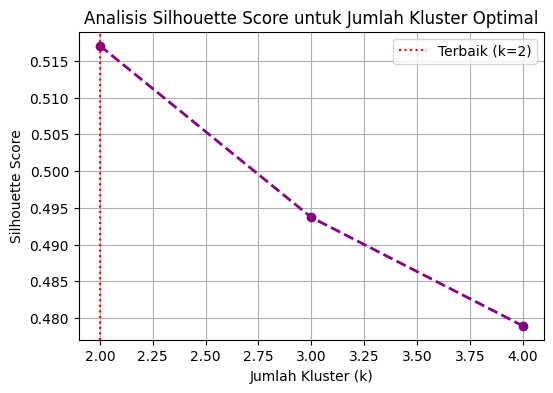

In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Load data matriks jarak aktual yang sudah kita simpan
file_matriks_jarak = 'distance_matrix_surabaya.csv'

try:
    df_distance = pd.read_csv(file_matriks_jarak, index_col=0)
    
    # Keluarkan Hotel Sheraton karena clustering hanya fokus ke titik wisata tujuan
    df_distance_nodes = df_distance.drop(index="Hotel Sheraton Surabaya", columns="Hotel Sheraton Surabaya")
    matrix_precomputed = df_distance_nodes.loc[df_distance_nodes.index, df_distance_nodes.index].to_numpy()
    
    jumlah_destinasi = len(matrix_precomputed)
    
    # Menyiapkan list untuk menampung hasil pengujian
    range_kluster = range(2, min(5, jumlah_destinasi)) # Disesuaikan dengan batas jumlah data awal
    list_silhouette = []
    
    print("====== ANALISIS PENENTUAN JUMLAH KLUSTER ======\n")
    
    for n in range_kluster:
        # Jalankan Hierarchical Clustering dengan matriks jarak kustom
        cluster_model = AgglomerativeClustering(metric='precomputed', linkage='average', n_clusters=n)
        labels = cluster_model.fit_predict(matrix_precomputed)
        
        # Hitung Silhouette Score
        score = silhouette_score(matrix_precomputed, labels, metric='precomputed')
        list_silhouette.append(score)
        
        print(f"Jumlah Kluster = {n} | Silhouette Score: {score:.4f}")
        
    # Menentukan jumlah kluster terbaik berdasarkan score tertinggi
    idx_terbaik = np.argmax(list_silhouette)
    kluster_terbaik = range_kluster[idx_terbaik]
    print(f"\nRekomendasi sistem secara matematis: {kluster_terbaik} Kluster adalah yang paling optimal.")

    # 3. Visualisasi Grafik Silhouette Score
    plt.figure(figsize=(6, 4))
    plt.plot(range_kluster, list_silhouette, marker='o', color='purple', linestyle='dashed', linewidth=2)
    plt.title('Analisis Silhouette Score untuk Jumlah Kluster Optimal')
    plt.xlabel('Jumlah Kluster (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.axvline(x=kluster_terbaik, color='red', linestyle=':', label=f'Terbaik (k={kluster_terbaik})')
    plt.legend()
    plt.show()

except Exception as e:
    print(f"I'm sorry I can't. Terjadi kesalahan saat analisis: {e}")

In [4]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import folium

# 1. Load Data Tempat dan Matriks Jarak Aktual
file_destinasi = 'rute_sepeda_surabaya.csv'
file_matriks_jarak = 'distance_matrix_surabaya.csv'

try:
    df_wisata = pd.read_csv(file_destinasi)
    df_distance = pd.read_csv(file_matriks_jarak, index_col=0)
    
    # Ambil koordinat Hotel Sheraton untuk pusat peta visualisasi nanti
    nama_depot = "Hotel Sheraton Surabaya"
    depot_lat = -7.262015
    depot_lon = 112.739727
    
    # Keluarkan Hotel Sheraton dari proses clustering objek wisata
    df_distance_nodes = df_distance.drop(index=nama_depot, columns=nama_depot)
    
    # Ambil matriks jarak antar destinasi saja dalam bentuk NumPy array
    destinasi_names = df_wisata['Nama Destinasi'].tolist()
    matrix_precomputed = df_distance_nodes.loc[destinasi_names, destinasi_names].to_numpy()
    
    print("Menjalankan Hierarchical Clustering berbasis Jarak Aktual Jalanan...")
    
    # 2. Inisialisasi Model Clustering (Diubah menjadi 3 Kluster sesuai request)
    cluster_model = AgglomerativeClustering(
        n_clusters=3, 
        metric='precomputed', 
        linkage='average'
    )
    
    # 3. Fitting data untuk mendapatkan ID Kluster
    cluster_labels = cluster_model.fit_predict(matrix_precomputed)
    
    # 4. Masukkan kembali hasil kluster ke DataFrame destinasi
    df_wisata['Cluster_ID'] = cluster_labels
    
    # Simpan dataset yang sudah memiliki info kluster wilayah
    output_file = 'destinasi_clustered_real_distance.csv'
    df_wisata.to_csv(output_file, index=False)
    
    print("\n====== HASIL SPATIAL CLUSTERING (BERDASARKAN JARAK SEBENARNYA) ======\n")
    print(df_wisata[['No', 'Nama Destinasi', 'Daerah', 'Cluster_ID']].to_string(index=False))
    print(f"\nData kluster spasial berhasil disimpan ke: {output_file}")

    # =======================================================
    # TAHAP VISUALISASI HASIL CLUSTER MENGGUNAKAN FOLIUM
    # =======================================================
    print("\nMembuat peta visualisasi hasil kluster...")
    
    # Membuat base map, berpusat di Hotel Sheraton
    m = folium.Map(location=[depot_lat, depot_lon], zoom_start=15, control_scale=True)
    
    # 1. Tambahkan Marker Khusus untuk Depot (Hotel Sheraton) - Warna Merah
    popup_depot = f"<b>{nama_depot}</b><br>Kategori: Titik Start/Finish (Depot)"
    folium.Marker(
        location=[depot_lat, depot_lon],
        popup=folium.Popup(popup_depot, max_width=300),
        tooltip=nama_depot,
        icon=folium.Icon(color='red', icon='home')
    ).add_to(m)
    
    # Mapping warna marker berdasarkan Cluster ID (3 Kluster)
    # Kluster 0 = Hijau, Kluster 1 = Biru, Kluster 2 = Oranye
    warna_kluster = {0: 'green', 1: 'blue', 2: 'orange'}
    
    # 2. Tambahkan Marker untuk setiap destinasi berdasarkan kelompok klusternya
    for index, row in df_wisata.iterrows():
        id_kluster = int(row['Cluster_ID'])
        warna = warna_kluster.get(id_kluster, 'gray') # default gray jika di luar 0,1,2
        
        popup_text = f"<b>{row['Nama Destinasi']}</b><br>Daerah: {row['Daerah']}<br><b>Cluster ID: {id_kluster}</b>"
        
        folium.Marker(
            location=[row['Latitude'], row['Longitude']],
            popup=folium.Popup(popup_text, max_width=300),
            tooltip=row['Nama Destinasi'],
            icon=folium.Icon(color=warna, icon='info-sign')
        ).add_to(m)
        
    # Menyimpan peta ke file HTML baru
    map_output_file = 'peta_cluster_wisata.html'
    m.save(map_output_file)
    print(f"Peta visualisasi hasil kluster berhasil disimpan ke: {map_output_file}")
    print("Buka berkas HTML tersebut di browsermu untuk melihat perbedaan warna kelompok wilayahnya!")

except FileNotFoundError as e:
    print(f"I'm sorry I can't. Berkas data preprocessing belum lengkap: {e}")
except Exception as e:
    print(f"I'm sorry I can't. Terjadi kesalahan teknis: {e}")

Menjalankan Hierarchical Clustering berbasis Jarak Aktual Jalanan...

====== HASIL SPATIAL CLUSTERING (BERDASARKAN JARAK SEBENARNYA) ======

 No                       Nama Destinasi  Daerah  Cluster_ID
  1                   Alun-Alun Surabaya   Pusat           2
  2                      Jalan Tunjungan   Pusat           2
  3                      Hotel Majapahit   Pusat           2
  4                Gedung Negara Grahadi   Pusat           2
  5                Monumen Bambu Runcing   Pusat           2
  6                         Taman Apsari   Pusat           2
  7                  Monumen Kapal Selam   Pusat           2
  8                       Plaza Surabaya   Pusat           2
  9                       Taman Prestasi   Pusat           2
 10                         Gedung Siola   Pusat           2
 11                        Pasar Blauran   Pusat           2
 12                  Jalan Basuki Rahmat   Pusat           2
 13                Monumen Tugu Pahlawan   Pusat           2
 14  

In [11]:
import pandas as pd
import numpy as np

# 1. Muat data destinasi yang sudah memiliki informasi Cluster_ID hasil clustering
file_clustered = 'destinasi_clustered_real_distance.csv'

try:
    df_wisata = pd.read_csv(file_clustered)
    
    # Inisialisasi daftar nama tempat (Depot Sheraton + 50 objek wisata)
    depot_name = "Hotel Sheraton Surabaya"
    names = [depot_name] + df_wisata['Nama Destinasi'].tolist()
    num_nodes = len(names)
    
    # 2. Bangun matriks kosong berukuran 51 x 51
    road_matrix = np.zeros((num_nodes, num_nodes))
    
    # 3. Isi skor kelayakan jalan secara dinamis berdasarkan kedekatan kluster geografis
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j:
                road_matrix[i][j] = 0.0  # Titik yang sama tidak ada penalti jalan
                continue
                
            # Aturan rute yang melibatkan Depot (Hotel Sheraton)
            if i == 0 or j == 0:
                # Menghubungkan titik awal ke tempat terdekat diberi skor normal
                road_matrix[i][j] = 3.0
                continue
            
            # Ambil Cluster_ID untuk objek wisata asal dan tujuan (indeks dikurangi 1 karena ada depot di awal list)
            cluster_asal = df_wisata.iloc[i-1]['Cluster_ID']
            cluster_tujuan = df_wisata.iloc[j-1]['Cluster_ID']
            
            # Logika Aturan Skor Penalti Kondisi Jalan:
            if cluster_asal == cluster_tujuan:
                # Jika dalam satu kluster wilayah yang sama, rute dinilai ramah sepeda (Jalan lokal/pedestrian)
                road_matrix[i][j] = 1.5
            else:
                # Jika lintas kluster, dianggap harus melewati jalan protokol besar yang padat kendaraan
                road_matrix[i][j] = 4.0
                
    # 4. Simpan hasil penyesuaian matriks kondisi jalan yang representatif
    df_road_matrix = pd.DataFrame(road_matrix, index=names, columns=names)
    output_file = 'road_condition_matrix_surabaya.csv'
    df_road_matrix.to_csv(output_file)
    
    print(f"====== ROAD CONDITION MATRIX SELESAI DIOPTIMALKAN ({num_nodes}x{num_nodes}) ======\n")
    print(df_road_matrix.iloc[:6, :6].round(2)) # Tampilkan cuplikan matriks 6x6 teratas
    print(f"\nMatriks kondisi jalan berbasis kedekatan wilayah disimpan ke: {output_file}")
    print("Sekarang dasar data kondisi jalanmu jauh lebih logis untuk dioptimasi oleh ACO!")

except FileNotFoundError:
    print(f"I'm sorry I can't. Jalankan tahap clustering spasial terlebih dahulu untuk menghasilkan '{file_clustered}'.")
except Exception as e:
    print(f"I'm sorry I can't. Terjadi kesalahan: {e}")

====== ROAD CONDITION MATRIX SELESAI DIOPTIMALKAN (51x51) ======

                         Hotel Sheraton Surabaya  Alun-Alun Surabaya  \
Hotel Sheraton Surabaya                      0.0                 3.0   
Alun-Alun Surabaya                           3.0                 0.0   
Jalan Tunjungan                              3.0                 1.5   
Hotel Majapahit                              3.0                 1.5   
Gedung Negara Grahadi                        3.0                 1.5   
Monumen Bambu Runcing                        3.0                 1.5   

                         Jalan Tunjungan  Hotel Majapahit  \
Hotel Sheraton Surabaya              3.0              3.0   
Alun-Alun Surabaya                   1.5              1.5   
Jalan Tunjungan                      0.0              1.5   
Hotel Majapahit                      1.5              0.0   
Gedung Negara Grahadi                1.5              1.5   
Monumen Bambu Runcing                1.5              1.5   

 

In [10]:
import pandas as pd
import numpy as np
import random

# =====================================================================
# 1. REKALIBRASI FUNGSI FITNESS (PURE SOFT CONSTRAINTS)
# =====================================================================
def hitung_fitness_aco_personalized(solusi_rute_semut, matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user):
    """
    Fungsi Fitness Evaluasi Berbasis Soft Constraints Murni.
    Semua pelanggaran (Jarak & Fatigue) dihukum di sini, bukan dihentikan di jalan.
    """
    max_meter_user = max_km_user * 1000
    
    # Skala pembobotan yang sudah dikalibrasi ulang agar seimbang dengan satuan meter
    w_jarak = 1.0         # 20.000 meter = 20.000 score
    w_jalan = 50.0        # Akumulasi skor kelayakan jalan
    w_penalti_cluster_pindah = 500.0  # Heuristic guidance tidak mendominasi total jarak
    w_sanksi_kluster_terbengkalai = 2000.0 
    
    fitness_total = 0.0
    log_itinerary = []
    
    total_node_per_cluster = df_cluster['Cluster_ID'].value_counts().to_dict()
    nodes_dikunjungi = set()
    
    for idx_hari, rute in enumerate(solusi_rute_semut, start=1):
        # DINAMIKA KARAKTERISTIK HARI (SABTU VS MINGGU) DI FUNGSI FITNESS
        if idx_hari % 2 != 0:
            nama_hari = "Sabtu (Jalan Berat Lebih Ditoleransi)"
            w_penalti_fatigue = 10.0   # Penalti fatigue lebih longgar/kecil
            w_penalti_jarak = 2.0      # Penalti kelebihan Km standar
        else:
            nama_hari = "Minggu (Rute Santai & Recovery Diutamakan)"
            w_penalti_fatigue = 100.0  # Penalti fatigue sangat kejam agar model cari rute landai
            w_penalti_jarak = 15.0     # Penalti jarak sangat ketat agar tidak kelelahan sebelum Senin
            
        jarak_hari_ini = 0.0
        fatigue_hari_ini = 0.0
        skor_jalan_hari_ini = 0.0
        penalti_cluster_hari = 0.0
        sanksi_terbengkalai_hari = 0.0
        
        for k in range(len(rute) - 1):
            asal = rute[k]
            tujuan = rute[k+1]
            
            dist = matriks_jarak.iloc[asal, tujuan]
            delta_z = matriks_elevasi.iloc[asal, tujuan]
            jalan_skor = matriks_jalan.iloc[asal, tujuan]
            
            jarak_hari_ini += dist
            skor_jalan_hari_ini += jalan_skor
            
            # Formula Fatigue Terkalibrasi (Menggunakan desimal kelandaian murni)
            if delta_z > 0 and dist > 0:
                gradien = delta_z / dist # Desimal murni, bukan persentase ratusan
                fatigue_hari_ini += dist * (gradien ** 2) * 10.0
            else:
                fatigue_hari_ini += dist * 0.0001
                
            # Pelacakan aturan sisa node kluster terbengkalai
            if asal != 0 and tujuan != 0:
                cluster_asal = df_cluster.iloc[asal-1]['Cluster_ID']
                cluster_tujuan = df_cluster.iloc[tujuan-1]['Cluster_ID']
                
                nodes_dikunjungi.add(asal)
                
                if cluster_asal != cluster_tujuan:
                    penalti_cluster_hari += w_penalti_cluster_pindah
                    
                    nodes_cluster_asal_selesai = sum(1 for n in nodes_dikunjungi if df_cluster.iloc[n-1]['Cluster_ID'] == cluster_asal)
                    total_node_di_cluster_asal = total_node_per_cluster[cluster_asal]
                    sisa_node_persen = (total_node_di_cluster_asal - nodes_cluster_asal_selesai) / total_node_di_cluster_asal
                    
                    if sisa_node_persen >= 0.45:
                        sanksi_terbengkalai_hari += w_sanksi_kluster_terbengkalai
            elif tujuan != 0:
                nodes_dikunjungi.add(tujuan)
                    
        # Perhitungan penalti berbasis soft constraint murni
        penalti_jarak_hari = max(0.0, jarak_hari_ini - max_meter_user) * w_penalti_jarak
        penalti_fatigue_hari = fatigue_hari_ini * w_penalti_fatigue
        
        # Nilai dasar tanpa pengurangan reward berlebih untuk menghindari flag nilai negatif
        fitness_hari_ini = (
            (jarak_hari_ini * w_jarak) + 
            (skor_jalan_hari_ini * w_jalan) + 
            penalti_jarak_hari + 
            penalti_fatigue_hari + 
            penalti_cluster_hari + 
            sanksi_terbengkalai_hari
        )
        
        fitness_total += fitness_hari_ini
        
        log_itinerary.append({
            "Hari": f"Trip {idx_hari} ({nama_hari})",
            "Jarak (Km)": round(jarak_hari_ini / 1000, 2),
            "Fatigue Index": round(fatigue_hari_ini, 2),
            "Penalti Jarak": round(penalti_jarak_hari, 2),
            "Sanksi Terbengkalai": round(sanksi_terbengkalai_hari, 2)
        })
        
    return fitness_total, log_itinerary

# =====================================================================
# 2. CORE ENGINE ACO: REKONSTRUKSI TOTAL (EKSPLORASI BEBAS)
# =====================================================================
def jalankan_aco_routing_personalized(matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user, n_semut=15, n_iterasi=30):
    num_nodes = len(matriks_jarak)
    max_meter_user = max_km_user * 1000
    
    alpha = 1.0       
    beta = 2.0        
    evaporasi = 0.1   
    q_konstanta = 5000 
    
    pheromone = np.full((num_nodes, num_nodes), 0.1)
    
    solusi_terbaik = None
    fitness_terbaik = float('inf')
    log_itinerary_terbaik = None
    
    print(f"Memulai Optimasi ACO untuk {num_nodes-1} destinasi dengan batas {max_km_user} Km/hari (Soft Constraints)...")
    
    for iterasi in range(1, n_iterasi + 1):
        list_solusi_semut = []
        list_fitness_semut = []
        list_log_semut = []
        
        for semut in range(n_semut):
            destinasi_tersisa = list(range(1, num_nodes))
            rute_multi_hari = []
            
            while len(destinasi_tersisa) > 0:
                rute_hari_ini = [0] 
                jarak_akumulasi_hari = 0.0
                
                while len(destinasi_tersisa) > 0:
                    posisi_sekarang = rute_hari_ini[-1]
                    
                    probabilitas = []
                    for tujuan in destinasi_tersisa:
                        tau = pheromone[posisi_sekarang][tujuan] ** alpha
                        
                        dist_ij = matriks_jarak.iloc[posisi_sekarang, tujuan]
                        jalan_ij = matriks_jalan.iloc[posisi_sekarang, tujuan]
                        
                        # ACO INTEGRASI SPASIAL LOCAL: Jika pindah kluster saat konstruksi, berikan beban lokal pada eta
                        beban_cluster_local = 0.0
                        if posisi_sekarang != 0 and tujuan != 0:
                            cluster_asal = df_cluster.iloc[posisi_sekarang-1]['Cluster_ID']
                            cluster_tujuan = df_cluster.iloc[tujuan-1]['Cluster_ID']
                            if cluster_asal != cluster_tujuan:
                                beban_cluster_local = 500.0 # Semut tahu secara insting daerah ini jauh lintas kluster
                        
                        # Nilai Heuristic Heuristic bimbingan komprehensif semut
                        eta = 1.0 / (dist_ij + jalan_ij * 5 + beban_cluster_local + 0.1)
                        probabilitas.append(tau * (eta ** beta))
                        
                    sum_prob = sum(probabilitas)
                    if sum_prob == 0:
                        prob_normalisasi = [1.0 / len(destinasi_tersisa)] * len(destinasi_tersisa)
                    else:
                        prob_normalisasi = [p / sum_prob for p in probabilitas]
                        
                    pilihan_tujuan = random.choices(destinasi_tersisa, weights=prob_normalisasi, k=1)[0]
                    uji_jarak = matriks_jarak.iloc[posisi_sekarang, pilihan_tujuan]
                    
                    # LOGIKA POTONG SOFT CONSTRAINT: Semut memperkirakan jika langkah ini melebihi target harian,
                    # semut disarankan pulang, namun tetap diberi kebebasan eksplorasi acak kecil (tidak dikunci kaku)
                    if (jarak_akumulasi_hari + uji_jarak > max_meter_user) and (random.random() > 0.15):
                        break
                        
                    rute_hari_ini.append(pilihan_tujuan)
                    jarak_akumulasi_hari += uji_jarak
                    destinasi_tersisa.remove(pilihan_tujuan)
                    
                rute_hari_ini.append(0)
                rute_multi_hari.append(rute_hari_ini)
                
            # Memanggil fungsi fitness penalti kluster terkalibrasi (Perbaikan Bug No 3)
            fitness_semut, log_semut = hitung_fitness_aco_personalized(
                rute_multi_hari, matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user
            )
            
            list_solusi_semut.append(rute_multi_hari)
            list_fitness_semut.append(fitness_semut)
            list_log_semut.append(log_semut)
            
            if ... and fitness_semut < fitness_terbaik:
                fitness_terbaik = fitness_semut
                solusi_terbaik = rute_multi_hari
                log_itinerary_terbaik = log_semut
                
        # Update Pheromone global
        pheromone *= (1.0 - evaporasi)
        for idx_semut, solusi in enumerate(list_solusi_semut):
            fit_value = list_fitness_semut[idx_semut]
            if fit_value > 0:
                deposit = q_konstanta / fit_value
                for rute in solusi:
                    for k in range(len(rute) - 1):
                        pheromone[rute[k]][rute[k+1]] += deposit

        if iterasi % 5 == 0 or iterasi == 1:
            print(f" Iterasi {iterasi:02d} | Fitness Terbaik Global: {round(fitness_terbaik, 2)}")
            
    return solusi_terbaik, fitness_terbaik, log_itinerary_terbaik

# =====================================================================
# RUN SCRIPT
# =====================================================================
if __name__ == "__main__":
    try:
        matriks_jarak = pd.read_csv('distance_matrix_surabaya.csv', index_col=0)
        matriks_elevasi = pd.read_csv('elevation_matrix_surabaya.csv', index_col=0)
        matriks_jalan = pd.read_csv('road_condition_matrix_surabaya.csv', index_col=0)
        df_cluster = pd.read_csv('destinasi_clustered_real_distance.csv')
        
        input_user_km = 20.0 
        
        rute_final, fitness_final, itinerary_final = jalankan_aco_routing_personalized(
            matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user=input_user_km, n_semut=15, n_iterasi=30
        )
        
        print("\n=======================================================")
        print("====== REKONSTRUKSI HASIL OPTIMASI ITINERARY ACO ======")
        print("=======================================================")
        print(pd.DataFrame(itinerary_final).to_string(index=False))
        print(f"\nSkor Fitness Akhir Terkalibrasi Murni: {round(fitness_final, 2)}")
        
    except FileNotFoundError as e:
        print(f"I'm sorry I can't. Berkas preprocessing tidak lengkap: {e}")

Memulai Optimasi ACO untuk 50 destinasi dengan batas 20.0 Km/hari (Soft Constraints)...
 Iterasi 01 | Fitness Terbaik Global: 170158.02


KeyboardInterrupt: 

In [7]:
import pandas as pd
import numpy as np
import random

# =====================================================================
# 1. FUNGSI FITNESS TERKALIBRASI (PENYELARASAN SKALA KOMPONEN)
# =====================================================================
def hitung_fitness_aco_calibrated(solusi_rute_semut, matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user):
    """
    Fungsi Fitness dengan penyetaraan skala komponen (Km murni, no meter)
    untuk menghindari bias optimasi.
    """
    # Bobot komponen yang sudah diselaraskan skalanya
    w_jarak = 10.0         # Jarak 15 Km -> 150 poin
    w_jalan = 5.0          # Skor jalan 30 -> 150 poin
    w_penalti_cluster = 50.0 # Penalti pindah wilayah (Soft Guidance)
    
    fitness_total = 0.0
    log_itinerary = []
    
    for idx_hari, rute in enumerate(solusi_rute_semut, start=1):
        # Aturan Preferensi Hari Sabtu vs Minggu
        if idx_hari % 2 != 0:
            nama_hari = "Sabtu (Jalan Berat)"
            w_penalti_fatigue = 2.0   # Fatigue tidak terlalu dihukum di hari Sabtu
            w_penalti_jarak = 5.0     # Penalti jika lewat dari batas Km user
        else:
            nama_hari = "Minggu (Recovery)"
            w_penalti_fatigue = 15.0  # Fatigue dihukum berat di hari Minggu (Recovery Mode)
            w_penalti_jarak = 25.0    # Jarak lewat batas dihukum sangat kejam
            
        jarak_hari_meter = 0.0
        fatigue_hari_ini = 0.0
        skor_jalan_hari_ini = 0.0
        penalti_cluster_hari = 0.0
        
        for k in range(len(rute) - 1):
            asal = rute[k]
            tujuan = rute[k+1]
            
            dist_meter = matriks_jarak.iloc[asal, tujuan]
            delta_z = matriks_elevasi.iloc[asal, tujuan]
            jalan_skor = matriks_jalan.iloc[asal, tujuan]
            
            jarak_hari_meter += dist_meter
            skor_jalan_hari_ini += jalan_skor
            
            # Formula Fatigue Terkalibrasi (Desimal murni)
            if delta_z > 0 and dist_meter > 0:
                gradien = delta_z / dist_meter
                fatigue_hari_ini += dist_meter * (gradien ** 2) * 10.0
            else:
                fatigue_hari_ini += dist_meter * 0.0001
                
            # Penalti Pindah Cluster Ringan (Tanpa Sanksi Terbengkalai yang brutal)
            if asal != 0 and tujuan != 0:
                cluster_asal = df_cluster.iloc[asal-1]['Cluster_ID']
                cluster_tujuan = df_cluster.iloc[tujuan-1]['Cluster_ID']
                if cluster_asal != cluster_tujuan:
                    penalti_cluster_hari += w_penalti_cluster

        # Konversi total jarak ke Kilometer untuk fungsi fitness
        jarak_hari_km = jarak_hari_meter / 1000.0
        
        # Hitung penalti soft constraint
        penalti_jarak_hari = max(0.0, jarak_hari_km - max_km_user) * w_penalti_jarak
        penalti_fatigue_hari = fatigue_hari_ini * w_penalti_fatigue
        
        # Kalkulasi nilai objektif hari ini (Semua komponen berada di skala puluhan-ratusan)
        fitness_hari_ini = (
            (jarak_hari_km * w_jarak) + 
            (skor_jalan_hari_ini * w_jalan) + 
            penalti_jarak_hari + 
            penalti_fatigue_hari + 
            penalti_cluster_hari
        )
        
        fitness_total += fitness_hari_ini
        
        log_itinerary.append({
            "Hari": f"Trip {idx_hari} ({nama_hari})",
            "Jarak (Km)": round(jarak_hari_km, 2),
            "Fatigue Index": round(fatigue_hari_ini, 2),
            "Skor Jalan": round(skor_jalan_hari_ini, 2),
            "P_Jarak": round(penalti_jarak_hari, 2),
            "P_Fatigue": round(penalti_fatigue_hari, 2),
            "P_Cluster": round(penalti_cluster_hari, 2)
        })
        
    return fitness_total, log_itinerary

# =====================================================================
# 2. CORE ENGINE ACO UTUH (BUG-FREE & CALIBRATED SELECTION)
# =====================================================================
def jalankan_aco_routing_calibrated(matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user, n_semut=15, n_iterasi=30):
    num_nodes = len(matriks_jarak)
    max_meter_user = max_km_user * 1000
    
    alpha = 1.0       
    beta = 2.0        
    evaporasi = 0.1   
    q_konstanta = 2000 
    
    pheromone = np.full((num_nodes, num_nodes), 0.1)
    
    solusi_terbaik = None
    fitness_terbaik = float('inf')
    log_itinerary_terbaik = None
    
    print(f"Memulai Optimasi ACO untuk {num_nodes-1} destinasi dengan batas {max_km_user} Km/hari...")
    
    for iterasi in range(1, n_iterasi + 1):
        list_solusi_semut = []
        list_fitness_semut = []
        list_log_semut = []
        
        for semut in range(n_semut):
            destinasi_tersisa = list(range(1, num_nodes))
            rute_multi_hari = []
            
            while len(destinasi_tersisa) > 0:
                rute_hari_ini = [0] 
                jarak_akumulasi_hari = 0.0
                
                while len(destinasi_tersisa) > 0:
                    posisi_sekarang = rute_hari_ini[-1]
                    
                    probabilitas = []
                    for tujuan in destinasi_tersisa:
                        tau = pheromone[posisi_sekarang][tujuan] ** alpha
                        
                        dist_ij = matriks_jarak.iloc[posisi_sekarang, tujuan]
                        jalan_ij = matriks_jalan.iloc[posisi_sekarang, tujuan]
                        
                        # ACO SPASIAL LOCAL PENGARUH DIKECILKAN (Koreksi No 3)
                        beban_cluster_local = 0.0
                        if posisi_sekarang != 0 and tujuan != 0:
                            cluster_asal = df_cluster.iloc[posisi_sekarang-1]['Cluster_ID']
                            cluster_tujuan = df_cluster.iloc[tujuan-1]['Cluster_ID']
                            if cluster_asal != cluster_tujuan:
                                bimbingan_cluster_local = 150.0 
                        
                        eta = 1.0 / (dist_ij + jalan_ij * 5 + beban_cluster_local + 0.1)
                        probabilitas.append(tau * (eta ** beta))
                        
                    sum_prob = sum(probabilitas)
                    if sum_prob == 0:
                        prob_normalisasi = [1.0 / len(destinasi_tersisa)] * len(destinasi_tersisa)
                    else:
                        prob_normalisasi = [p / sum_prob for p in probabilitas]
                        
                    pilihan_tujuan = random.choices(destinasi_tersisa, weights=prob_normalisasi, k=1)[0]
                    uji_jarak = matriks_jarak.iloc[posisi_sekarang, pilihan_tujuan]
                    
                    if (jarak_akumulasi_hari + uji_jarak > max_meter_user) and (random.random() > 0.15):
                        break
                        
                    rute_hari_ini.append(pilihan_tujuan)
                    jarak_akumulasi_hari += uji_jarak
                    destinasi_tersisa.remove(pilihan_tujuan)
                    
                rute_hari_ini.append(0)
                rute_multi_hari.append(rute_hari_ini)
                
            # Evaluasi Kualitas Rute
            fitness_semut, log_semut = hitung_fitness_aco_calibrated(
                rute_multi_hari, matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user
            )
            
            list_solusi_semut.append(rute_multi_hari)
            list_fitness_semut.append(fitness_semut)
            list_log_semut.append(log_semut)
            
            # PERBAIKAN BUG UTAMA (Koreksi No 1 - Menghapus Tanda Titik Tiga)
            if fitness_semut < fitness_terbaik:
                fitness_terbaik = fitness_semut
                solusi_terbaik = rute_multi_hari
                log_itinerary_terbaik = log_semut
                
        # Update Pheromone
        pheromone *= (1.0 - evaporasi)
        for idx_semut, solusi in enumerate(list_solusi_semut):
            fit_value = list_fitness_semut[idx_semut]
            if fit_value > 0:
                deposit = q_konstanta / fit_value
                for rute in solusi:
                    for k in range(len(rute) - 1):
                        pheromone[rute[k]][rute[k+1]] += deposit

        if iterasi % 5 == 0 or iterasi == 1:
            print(f" Iterasi {iterasi:02d} | Fitness Terbaik Global: {round(fitness_terbaik, 2)}")
            
    return solusi_terbaik, fitness_terbaik, log_itinerary_terbaik

# =====================================================================
# MONITORING RUN SCRIPT
# =====================================================================
if __name__ == "__main__":
    try:
        matriks_jarak = pd.read_csv('distance_matrix_surabaya.csv', index_col=0)
        matriks_elevasi = pd.read_csv('elevation_matrix_surabaya.csv', index_col=0)
        matriks_jalan = pd.read_csv('road_condition_matrix_surabaya.csv', index_col=0)
        df_cluster = pd.read_csv('destinasi_clustered_real_distance.csv')
        
        input_user_km = 20.0 
        
        rute_final, fitness_final, itinerary_final = jalankan_aco_routing_calibrated(
            matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user=input_user_km, n_semut=15, n_iterasi=30
        )
        
        print("\n=======================================================")
        print("====== MONITORING SKALA KOMPONEN ITINERARY ACO ======")
        print("=======================================================")
        print(pd.DataFrame(itinerary_final).to_string(index=False))
        print(f"\nSkor Fitness Akhir Terkalibrasi Murni: {round(fitness_final, 2)}")
        
    except FileNotFoundError as e:
        print(f"I'm sorry I can't. Gagal memuat berkas komponen: {e}")

Memulai Optimasi ACO untuk 50 destinasi dengan batas 20.0 Km/hari...
 Iterasi 01 | Fitness Terbaik Global: 2153.51
 Iterasi 05 | Fitness Terbaik Global: 1491.59
 Iterasi 10 | Fitness Terbaik Global: 1479.21
 Iterasi 15 | Fitness Terbaik Global: 1372.93
 Iterasi 20 | Fitness Terbaik Global: 1351.33
 Iterasi 25 | Fitness Terbaik Global: 1333.87
 Iterasi 30 | Fitness Terbaik Global: 1315.14

====== MONITORING SKALA KOMPONEN ITINERARY ACO ======
                        Hari  Jarak (Km)  Fatigue Index  Skor Jalan  P_Jarak  P_Fatigue  P_Cluster
Trip 1 (Sabtu (Jalan Berat))       27.60           2.99        37.0    37.99       5.98       50.0
  Trip 2 (Minggu (Recovery))       20.13           3.50        34.5     3.31      52.49        0.0
Trip 3 (Sabtu (Jalan Berat))       21.85           2.63        19.5     9.26       5.27        0.0

Skor Fitness Akhir Terkalibrasi Murni: 1315.14


Memuat data preprocessing...

  GENETIC ALGORITHM — Route Optimization Sepeda
  Destinasi  : 50 titik wisata
  Populasi   : 100 individu
  Generasi   : 100
  Seleksi    : Tournament (k=5)
  Crossover  : Order Crossover (OX), p=0.85
  Mutasi     : Swap Mutation, p=0.15
  Elitism    : 2 individu terbaik
  Max Km/hari: 20.0 km (soft constraint)

  Gen 001 | Best: 4,685.18 | Avg: 5,709.92 | Hari: 13
  Gen 010 | Best: 3,479.00 | Avg: 4,495.57 | Hari: 9
  Gen 020 | Best: 2,843.18 | Avg: 3,372.93 | Hari: 9
  Gen 030 | Best: 2,825.95 | Avg: 3,327.46 | Hari: 9
  Gen 040 | Best: 2,690.81 | Avg: 3,115.09 | Hari: 9
  Gen 050 | Best: 2,680.93 | Avg: 3,274.66 | Hari: 9
  Gen 060 | Best: 2,623.69 | Avg: 3,160.87 | Hari: 9
  Gen 070 | Best: 2,599.86 | Avg: 3,144.64 | Hari: 9
  Gen 080 | Best: 2,462.09 | Avg: 3,002.34 | Hari: 9
  Gen 090 | Best: 2,446.01 | Avg: 3,016.43 | Hari: 9
  Gen 100 | Best: 2,440.79 | Avg: 2,860.03 | Hari: 9

  Optimasi selesai!
  Fitness terbaik : 2,440.79
  Jumlah hari     : 9

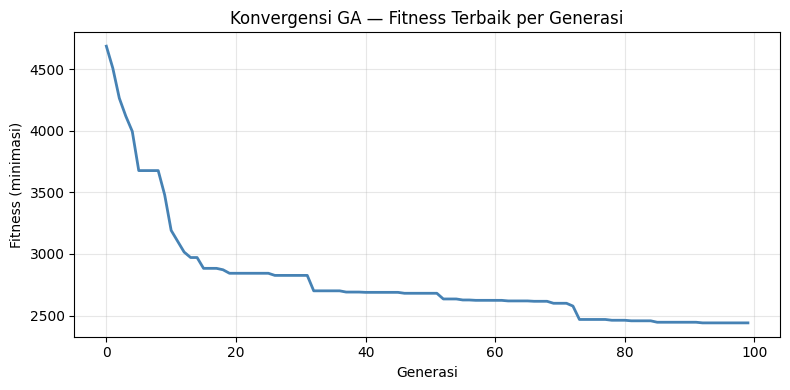

Grafik konvergensi disimpan ke: konvergensi_ga.png

  HASIL AKHIR GA (Tanpa Overpass API)
  Fitness Final : 2,440.79
  Jumlah Trip   : 9 hari


In [12]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║         GENETIC ALGORITHM - ROUTE OPTIMIZATION SEPEDA           ║
# ║         Tugas Kelompok - Bagian: Genetic Algorithm (GA)         ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# Kompatibel dengan pipeline temanmu:
#   Input : distance_matrix_surabaya.csv
#           elevation_matrix_surabaya.csv
#           road_condition_matrix_surabaya.csv   <- Cell A: proxy cluster
#           road_condition_matrix_surabaya.csv   <- Cell B: Overpass API
#           destinasi_clustered_real_distance.csv
#   Output: itinerary_ga.csv + peta_rute_ga.html
#
# ══════════════════════════════════════════════════════════════════


# ╔══════════════════════════════════════╗
# ║  CELL A — GA TANPA OVERPASS API     ║
# ║  (Road condition = proxy cluster)   ║
# ╚══════════════════════════════════════╝

import pandas as pd
import numpy as np
import random
import copy

# ─────────────────────────────────────────────
# PARAMETER GA
# ─────────────────────────────────────────────
POP_SIZE      = 100   # jumlah individu dalam populasi
N_GENERASI    = 100   # jumlah generasi
TOURNAMENT_K  = 5     # ukuran tournament (semakin besar = semakin selektif)
PROB_CROSSOVER = 0.85  # probabilitas crossover
PROB_MUTASI    = 0.15  # probabilitas mutasi per individu
N_ELITE        = 2    # jumlah individu terbaik yang langsung lolos (elitism)
MAX_KM_USER    = 20.0  # batas jarak harian (soft constraint)

# ─────────────────────────────────────────────
# 1. FUNGSI FITNESS
# (sama persis dengan temanmu — hitung_fitness_aco_calibrated)
# ─────────────────────────────────────────────
def hitung_fitness_ga(solusi_multi_hari, matriks_jarak, matriks_elevasi,
                      matriks_jalan, df_cluster, max_km_user=MAX_KM_USER):
    """
    Evaluasi kualitas satu solusi (individu GA).
    Solusi = list of list: [[0,3,7,12,0], [0,5,9,0], ...]
    Setiap sublist = rute 1 hari, selalu mulai & kembali ke depot (index 0).
    Return: (fitness_total: float, log_itinerary: list of dict)
    """
    w_jarak          = 10.0
    w_jalan          = 5.0
    w_penalti_cluster = 50.0

    fitness_total = 0.0
    log_itinerary = []

    for idx_hari, rute in enumerate(solusi_multi_hari, start=1):
        # Karakteristik hari: Sabtu (ganjil) vs Minggu (genap)
        if idx_hari % 2 != 0:
            nama_hari        = "Sabtu (Jalan Berat)"
            w_penalti_fatigue = 2.0
            w_penalti_jarak   = 5.0
        else:
            nama_hari        = "Minggu (Recovery)"
            w_penalti_fatigue = 15.0
            w_penalti_jarak   = 25.0

        jarak_hari_meter  = 0.0
        fatigue_hari      = 0.0
        skor_jalan_hari   = 0.0
        penalti_cluster   = 0.0

        for k in range(len(rute) - 1):
            asal   = rute[k]
            tujuan = rute[k + 1]

            dist_meter = matriks_jarak.iloc[asal, tujuan]
            delta_z    = matriks_elevasi.iloc[asal, tujuan]
            jalan_skor = matriks_jalan.iloc[asal, tujuan]

            jarak_hari_meter += dist_meter
            skor_jalan_hari  += jalan_skor

            # Fatigue: tanjakan curam dihukum berat
            if delta_z > 0 and dist_meter > 0:
                gradien   = delta_z / dist_meter
                fatigue_hari += dist_meter * (gradien ** 2) * 10.0
            else:
                fatigue_hari += dist_meter * 0.0001

            # Penalti pindah cluster
            if asal != 0 and tujuan != 0:
                c_asal   = df_cluster.iloc[asal - 1]['Cluster_ID']
                c_tujuan = df_cluster.iloc[tujuan - 1]['Cluster_ID']
                if c_asal != c_tujuan:
                    penalti_cluster += w_penalti_cluster

        jarak_hari_km    = jarak_hari_meter / 1000.0
        penalti_jarak    = max(0.0, jarak_hari_km - max_km_user) * w_penalti_jarak
        penalti_fatigue  = fatigue_hari * w_penalti_fatigue

        fitness_hari = (
            jarak_hari_km   * w_jarak +
            skor_jalan_hari * w_jalan +
            penalti_jarak            +
            penalti_fatigue          +
            penalti_cluster
        )
        fitness_total += fitness_hari

        log_itinerary.append({
            "Hari"         : f"Trip {idx_hari} ({nama_hari})",
            "Jarak (Km)"   : round(jarak_hari_km, 2),
            "Fatigue Index": round(fatigue_hari, 2),
            "Skor Jalan"   : round(skor_jalan_hari, 2),
            "P_Jarak"      : round(penalti_jarak, 2),
            "P_Fatigue"    : round(penalti_fatigue, 2),
            "P_Cluster"    : round(penalti_cluster, 2),
        })

    return fitness_total, log_itinerary


# ─────────────────────────────────────────────
# 2. REPRESENTASI SOLUSI & SLICING
# ─────────────────────────────────────────────
def buat_kromosom_acak(n_destinasi=50):
    """
    Kromosom = permutasi acak dari index 1..50 (tanpa depot).
    Depot (index 0) disisipkan otomatis saat decode.
    """
    kromosom = list(range(1, n_destinasi + 1))
    random.shuffle(kromosom)
    return kromosom

def decode_kromosom(kromosom, matriks_jarak, max_km_user=MAX_KM_USER):
    """
    Potong kromosom (array 50 elemen) menjadi rute multi-hari.
    Setiap hari: depot → beberapa destinasi → depot.
    Batas jarak per hari = max_km_user (soft, ada toleransi 15%).
    """
    max_meter = max_km_user * 1000
    rute_multi_hari = []
    sisa = list(kromosom)

    while sisa:
        rute_hari = [0]  # mulai dari depot
        jarak_akumulasi = 0.0

        while sisa:
            posisi_sekarang = rute_hari[-1]
            kandidat        = sisa[0]
            jarak_tambah    = matriks_jarak.iloc[posisi_sekarang, kandidat]

            # Soft constraint: 15% chance tetap jalan walau sudah lewat batas
            if (jarak_akumulasi + jarak_tambah > max_meter) and (random.random() > 0.15):
                break

            rute_hari.append(kandidat)
            jarak_akumulasi += jarak_tambah
            sisa.pop(0)

        rute_hari.append(0)  # kembali ke depot
        rute_multi_hari.append(rute_hari)

    return rute_multi_hari


# ─────────────────────────────────────────────
# 3. OPERATOR GENETIKA
# ─────────────────────────────────────────────
def order_crossover(parent1, parent2):
    """
    Order Crossover (OX) — menjaga urutan relatif gen.
    Pilih substring dari parent1, isi sisanya dari urutan parent2.
    """
    n = len(parent1)
    a, b = sorted(random.sample(range(n), 2))

    anak = [None] * n
    anak[a:b+1] = parent1[a:b+1]

    sisa_parent2 = [g for g in parent2 if g not in anak[a:b+1]]
    ptr = 0
    for i in range(n):
        if anak[i] is None:
            anak[i] = sisa_parent2[ptr]
            ptr += 1

    return anak

def swap_mutation(kromosom, prob=PROB_MUTASI):
    """
    Swap Mutation — tukar posisi dua gen secara acak.
    Diterapkan jika random() < prob.
    """
    anak = kromosom[:]
    if random.random() < prob:
        i, j = random.sample(range(len(anak)), 2)
        anak[i], anak[j] = anak[j], anak[i]
    return anak

def tournament_selection(populasi, fitness_list, k=TOURNAMENT_K):
    """
    Tournament Selection: pilih k individu acak, kembalikan yang fitness-nya terkecil.
    """
    kandidat_idx = random.sample(range(len(populasi)), k)
    terbaik_idx  = min(kandidat_idx, key=lambda i: fitness_list[i])
    return populasi[terbaik_idx][:]


# ─────────────────────────────────────────────
# 4. MAIN ENGINE GA
# ─────────────────────────────────────────────
def jalankan_ga_routing(matriks_jarak, matriks_elevasi, matriks_jalan,
                        df_cluster, max_km_user=MAX_KM_USER,
                        pop_size=POP_SIZE, n_generasi=N_GENERASI,
                        n_elite=N_ELITE):
    """
    Genetic Algorithm untuk optimasi rute sepeda multi-hari.
    Return: (solusi_terbaik, fitness_terbaik, log_itinerary_terbaik)
    """
    n_destinasi = len(matriks_jarak) - 1  # 50 destinasi (tanpa depot)

    print(f"{'='*58}")
    print(f"  GENETIC ALGORITHM — Route Optimization Sepeda")
    print(f"{'='*58}")
    print(f"  Destinasi  : {n_destinasi} titik wisata")
    print(f"  Populasi   : {pop_size} individu")
    print(f"  Generasi   : {n_generasi}")
    print(f"  Seleksi    : Tournament (k={TOURNAMENT_K})")
    print(f"  Crossover  : Order Crossover (OX), p={PROB_CROSSOVER}")
    print(f"  Mutasi     : Swap Mutation, p={PROB_MUTASI}")
    print(f"  Elitism    : {n_elite} individu terbaik")
    print(f"  Max Km/hari: {max_km_user} km (soft constraint)")
    print(f"{'='*58}\n")

    # ── Inisialisasi populasi awal ──
    populasi = [buat_kromosom_acak(n_destinasi) for _ in range(pop_size)]

    solusi_terbaik       = None
    fitness_terbaik      = float('inf')
    log_itinerary_terbaik = None
    history_fitness      = []

    for gen in range(1, n_generasi + 1):

        # ── Evaluasi seluruh populasi ──
        fitness_list = []
        log_list     = []
        for kromo in populasi:
            rute   = decode_kromosom(kromo, matriks_jarak, max_km_user)
            fit, lg = hitung_fitness_ga(rute, matriks_jarak, matriks_elevasi,
                                         matriks_jalan, df_cluster, max_km_user)
            fitness_list.append(fit)
            log_list.append(lg)

        # ── Update solusi terbaik global ──
        idx_terbaik_gen = int(np.argmin(fitness_list))
        if fitness_list[idx_terbaik_gen] < fitness_terbaik:
            fitness_terbaik       = fitness_list[idx_terbaik_gen]
            solusi_terbaik        = decode_kromosom(
                populasi[idx_terbaik_gen], matriks_jarak, max_km_user
            )
            log_itinerary_terbaik = log_list[idx_terbaik_gen]

        history_fitness.append(fitness_terbaik)

        # ── Log progress ──
        if gen % 10 == 0 or gen == 1:
            rata2 = np.mean(fitness_list)
            print(f"  Gen {gen:03d} | Best: {fitness_terbaik:,.2f} | "
                  f"Avg: {rata2:,.2f} | "
                  f"Hari: {len(solusi_terbaik)}")

        # ── Elitism: simpan N individu terbaik ──
        sorted_idx = np.argsort(fitness_list)
        elit       = [populasi[i][:] for i in sorted_idx[:n_elite]]

        # ── Buat generasi baru ──
        generasi_baru = elit[:]  # mulai dari individu elite

        while len(generasi_baru) < pop_size:
            # Seleksi parent
            p1 = tournament_selection(populasi, fitness_list)
            p2 = tournament_selection(populasi, fitness_list)

            # Crossover
            if random.random() < PROB_CROSSOVER:
                anak1 = order_crossover(p1, p2)
                anak2 = order_crossover(p2, p1)
            else:
                anak1, anak2 = p1[:], p2[:]

            # Mutasi
            anak1 = swap_mutation(anak1)
            anak2 = swap_mutation(anak2)

            generasi_baru.append(anak1)
            if len(generasi_baru) < pop_size:
                generasi_baru.append(anak2)

        populasi = generasi_baru

    print(f"\n  Optimasi selesai!")
    print(f"  Fitness terbaik : {fitness_terbaik:,.2f}")
    print(f"  Jumlah hari     : {len(solusi_terbaik)}")

    return solusi_terbaik, fitness_terbaik, log_itinerary_terbaik, history_fitness


# ─────────────────────────────────────────────
# 5. OUTPUT: CSV ITINERARY + PETA FOLIUM
# ─────────────────────────────────────────────
def simpan_output_ga(solusi, log_itinerary, df_wisata, history_fitness):
    import folium
    import matplotlib.pyplot as plt

    # — CSV Itinerary —
    df_log = pd.DataFrame(log_itinerary)
    df_log.to_csv('itinerary_ga.csv', index=False)
    print(f"\nItinerary disimpan ke: itinerary_ga.csv")
    print(df_log.to_string(index=False))

    # — Peta Folium —
    depot_lat, depot_lon = -7.262015, 112.739727
    names = ["Hotel Sheraton Surabaya"] + df_wisata['Nama Destinasi'].tolist()
    lats  = [depot_lat] + df_wisata['Latitude'].tolist()
    lons  = [depot_lon] + df_wisata['Longitude'].tolist()

    m = folium.Map(location=[depot_lat, depot_lon], zoom_start=13)

    warna_hari = ['red','blue','green','purple','orange',
                  'darkred','darkblue','darkgreen']

    folium.Marker(
        [depot_lat, depot_lon],
        tooltip="Hotel Sheraton (Depot)",
        icon=folium.Icon(color='red', icon='home')
    ).add_to(m)

    for idx_hari, rute in enumerate(solusi):
        warna = warna_hari[idx_hari % len(warna_hari)]
        koordinat_rute = [[lats[n], lons[n]] for n in rute]

        folium.PolyLine(
            koordinat_rute, color=warna,
            weight=3, opacity=0.8,
            tooltip=f"Trip {idx_hari+1}"
        ).add_to(m)

        for node in rute[1:-1]:  # skip depot
            folium.CircleMarker(
                [lats[node], lons[node]],
                radius=6, color=warna, fill=True,
                tooltip=f"[Trip {idx_hari+1}] {names[node]}"
            ).add_to(m)

    m.save('peta_rute_ga.html')
    print(f"Peta disimpan ke: peta_rute_ga.html")

    # — Grafik konvergensi fitness —
    plt.figure(figsize=(8, 4))
    plt.plot(history_fitness, color='steelblue', linewidth=2)
    plt.title('Konvergensi GA — Fitness Terbaik per Generasi')
    plt.xlabel('Generasi')
    plt.ylabel('Fitness (minimasi)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('konvergensi_ga.png', dpi=120)
    plt.show()
    print(f"Grafik konvergensi disimpan ke: konvergensi_ga.png")


# ─────────────────────────────────────────────
# RUN — CELL A (Tanpa Overpass API)
# ─────────────────────────────────────────────
if __name__ == "__main__":
    try:
        print("Memuat data preprocessing...\n")
        matriks_jarak    = pd.read_csv('distance_matrix_surabaya.csv',       index_col=0)
        matriks_elevasi  = pd.read_csv('elevation_matrix_surabaya.csv',      index_col=0)
        matriks_jalan    = pd.read_csv('road_condition_matrix_surabaya.csv', index_col=0)
        df_cluster       = pd.read_csv('destinasi_clustered_real_distance.csv')
        df_wisata        = pd.read_csv('rute_sepeda_surabaya.csv')

        # Jalankan GA
        rute_final, fitness_final, itinerary_final, history = jalankan_ga_routing(
            matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster
        )

        # Simpan output
        simpan_output_ga(rute_final, itinerary_final, df_wisata, history)

        print(f"\n{'='*58}")
        print(f"  HASIL AKHIR GA (Tanpa Overpass API)")
        print(f"  Fitness Final : {fitness_final:,.2f}")
        print(f"  Jumlah Trip   : {len(rute_final)} hari")
        print(f"{'='*58}")

    except FileNotFoundError as e:
        print(f"File tidak ditemukan: {e}")
    except Exception as e:
        import traceback
        traceback.print_exc()

In [8]:
import pandas as pd
import numpy as np
import requests
import time
import json
import os

# =====================================================================
# KONFIGURASI
# =====================================================================
OVERPASS_ENDPOINTS = [
    "https://overpass-api.de/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter",
]
REQUEST_TIMEOUT = 40
DELAY_ANTAR_REQUEST = 2.0  # detik antar batch request
CACHE_FILE = "osm_road_cache.json"  # cache hasil query per node
RADIUS_METER = 300  # radius area query per node (meter)

# =====================================================================
# 1. TABEL SCORING
# =====================================================================
HIGHWAY_SCORE = {
    "cycleway":       1.0,
    "path":           1.0,
    "footway":        1.2,
    "living_street":  1.5,
    "residential":    1.5,
    "unclassified":   2.0,
    "tertiary":       2.0,
    "tertiary_link":  2.0,
    "secondary":      3.0,
    "secondary_link": 3.0,
    "primary":        4.0,
    "primary_link":   4.0,
    "trunk":          5.0,
    "trunk_link":     5.0,
    "motorway":       5.0,
    "motorway_link":  5.0,
}

def hitung_skor_dari_tags(tags):
    highway = tags.get("highway", "")
    bicycle = tags.get("bicycle", "")
    width   = tags.get("width", None)

    skor = HIGHWAY_SCORE.get(highway, 2.5)

    # Modifier bicycle access
    if bicycle in ("designated", "yes"):
        skor -= 0.5
    elif bicycle == "no":
        skor += 1.5

    # Modifier width
    try:
        w = float(str(width).replace("m", "").strip())
        if w >= 5.0:
            skor -= 0.3
        elif w < 3.0:
            skor += 0.8
    except (ValueError, TypeError):
        pass

    return round(max(1.0, min(5.0, skor)), 3)

# =====================================================================
# 2. CACHE SYSTEM
# =====================================================================
def load_cache():
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE, "r") as f:
            print(f"Cache ditemukan: {CACHE_FILE}")
            return json.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f)

# =====================================================================
# 3. BATCH QUERY PER NODE
# =====================================================================
def query_overpass(overpass_ql):
    for endpoint in OVERPASS_ENDPOINTS:
        try:
            r = requests.post(
                endpoint,
                data={"data": overpass_ql},
                timeout=REQUEST_TIMEOUT,
                headers={"User-Agent": "RouteOptimizationResearch/1.0"}
            )
            if r.status_code == 200:
                return r.json().get("elements", [])
            else:
                print(f"   [HTTP {r.status_code}] {endpoint}")
        except requests.exceptions.Timeout:
            print(f"   [TIMEOUT] {endpoint}")
        except requests.exceptions.ConnectionError:
            print(f"   [CONNECTION ERROR] {endpoint}")
        except Exception as e:
            print(f"   [ERROR] {endpoint}: {e}")
    return None

def ambil_skor_area_node(lat, lon, node_idx):
    """
    Query SEMUA jalan di radius sekitar satu node.
    Return: skor terbaik (minimum) yang tersedia di area node tsb.
    
    Strategi: ambil representative score untuk area sekitar node ini,
    yang akan dipakai untuk semua edge yang berangkat dari node ini.
    """
    query = f"""
[out:json][timeout:35];
way(around:{RADIUS_METER},{lat},{lon})
  ["highway"]
  ["highway"!~"footway|steps|pedestrian|construction|proposed|abandoned|path"];
out tags;
"""
    elements = query_overpass(query)

    if elements is None or len(elements) == 0:
        return None

    skor_list = []
    for el in elements:
        tags = el.get("tags", {})
        if "highway" in tags:
            skor_list.append(hitung_skor_dari_tags(tags))

    if not skor_list:
        return None

    # Kembalikan dict statistik area: best, median, worst
    return {
        "best":   round(min(skor_list), 3),
        "median": round(float(np.median(skor_list)), 3),
        "worst":  round(max(skor_list), 3),
        "count":  len(skor_list)
    }

# =====================================================================
# 4. HITUNG SKOR EDGE i -> j DARI DATA AREA
# =====================================================================
def skor_edge_dari_area(area_i, area_j):
    """
    Skor edge i->j = rata-rata median area i dan area j.
    Logika: rute antara dua titik mencerminkan kondisi jalan
    di sekitar keduanya.
    """
    if area_i is None and area_j is None:
        return None
    if area_i is None:
        return area_j["median"]
    if area_j is None:
        return area_i["median"]
    return round((area_i["median"] + area_j["median"]) / 2, 3)

# =====================================================================
# 5. FALLBACK PROXY CLUSTER
# =====================================================================
def skor_fallback_cluster(i, j, df_cluster):
    if i == 0 or j == 0:
        return 3.0
    cluster_i = df_cluster.iloc[i - 1]['Cluster_ID']
    cluster_j = df_cluster.iloc[j - 1]['Cluster_ID']
    return 1.5 if cluster_i == cluster_j else 4.0

# =====================================================================
# 6. MAIN BUILDER (BATCH VERSION)
# =====================================================================
def bangun_road_condition_matrix_batch(
    df_wisata, df_cluster,
    output_file='road_condition_matrix_surabaya.csv'
):
    depot_name = "Hotel Sheraton Surabaya"
    depot_lat, depot_lon = -7.262015, 112.739727

    names = [depot_name] + df_wisata['Nama Destinasi'].tolist()
    lats  = [depot_lat]  + df_wisata['Latitude'].tolist()
    lons  = [depot_lon]  + df_wisata['Longitude'].tolist()
    num_nodes = len(names)

    # --- Load cache ---
    cache = load_cache()
    area_scores = {}  # node_idx -> area score dict

    print(f"{'='*55}")
    print(f"BATCH ROAD CONDITION MATRIX via Overpass API")
    print(f"{'='*55}")
    print(f"Jumlah node   : {num_nodes} (1 depot + {num_nodes-1} destinasi)")
    print(f"Target request: {num_nodes} batch (bukan {num_nodes*(num_nodes-1)})")
    print(f"Estimasi waktu: ~{num_nodes * (DELAY_ANTAR_REQUEST + 3) / 60:.1f} menit\n")

    # --- FASE 1: Query area score per node (51 request) ---
    print("FASE 1: Query Overpass per node...")
    api_ok = 0
    api_fallback = 0

    for idx in range(num_nodes):
        cache_key = f"node_{idx}_{lats[idx]:.5f}_{lons[idx]:.5f}"

        if cache_key in cache:
            area_scores[idx] = cache[cache_key]
            status = "CACHE"
        else:
            result = ambil_skor_area_node(lats[idx], lons[idx], idx)
            area_scores[idx] = result
            cache[cache_key] = result
            save_cache(cache)
            status = "API OK" if result else "FALLBACK"
            time.sleep(DELAY_ANTAR_REQUEST)

        if area_scores[idx] is not None:
            api_ok += 1
            info = f"median={area_scores[idx]['median']}, count={area_scores[idx]['count']}"
        else:
            api_fallback += 1
            info = "menggunakan fallback cluster"

        print(f"  [{idx+1:02d}/{num_nodes}] {names[idx][:35]:<35} | {status} | {info}")

    print(f"\nFase 1 selesai: {api_ok} node OK, {api_fallback} node fallback\n")

    # --- FASE 2: Bangun matriks dari area scores ---
    print("FASE 2: Membangun matriks 51x51 dari area scores...")
    road_matrix = np.zeros((num_nodes, num_nodes))
    fallback_count = 0

    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j:
                road_matrix[i][j] = 0.0
                continue

            skor = skor_edge_dari_area(area_scores[i], area_scores[j])

            if skor is not None:
                road_matrix[i][j] = skor
            else:
                road_matrix[i][j] = skor_fallback_cluster(i, j, df_cluster)
                fallback_count += 1

    total_edges = num_nodes * (num_nodes - 1)
    print(f"  Edge total        : {total_edges}")
    print(f"  Edge dari API     : {total_edges - fallback_count}")
    print(f"  Edge dari fallback: {fallback_count}")

    # --- Simpan output ---
    df_road = pd.DataFrame(road_matrix, index=names, columns=names)
    df_road.to_csv(output_file)

    print(f"\n{'='*55}")
    print(f"Road condition matrix disimpan ke: {output_file}")
    print(f"{'='*55}\n")

    print("Preview matriks (5x5 pertama):")
    print(df_road.iloc[:5, :5].round(3))

    # --- Ringkasan distribusi skor ---
    flat = road_matrix[road_matrix > 0].flatten()
    print(f"\nDistribusi skor kondisi jalan:")
    print(f"  Min    : {flat.min():.3f}")
    print(f"  Max    : {flat.max():.3f}")
    print(f"  Rata2  : {flat.mean():.3f}")
    print(f"  Median : {np.median(flat):.3f}")

    return df_road


# =====================================================================
# RUN SCRIPT
# =====================================================================
if __name__ == "__main__":
    try:
        df_wisata  = pd.read_csv('rute_sepeda_surabaya.csv')
        df_cluster = pd.read_csv('destinasi_clustered_real_distance.csv')

        road_matrix = bangun_road_condition_matrix_batch(df_wisata, df_cluster)

    except FileNotFoundError as e:
        print(f"File tidak ditemukan: {e}")
        print("Pastikan rute_sepeda_surabaya.csv dan destinasi_clustered_real_distance.csv sudah ada.")
    except Exception as e:
        print(f"Error: {e}")

BATCH ROAD CONDITION MATRIX via Overpass API
Jumlah node   : 51 (1 depot + 50 destinasi)
Target request: 51 batch (bukan 2550)
Estimasi waktu: ~4.2 menit

FASE 1: Query Overpass per node...
  [01/51] Hotel Sheraton Surabaya             | API OK | median=2.5, count=163
  [02/51] Alun-Alun Surabaya                  | API OK | median=2.5, count=149
  [03/51] Jalan Tunjungan                     | API OK | median=2.5, count=112
  [04/51] Hotel Majapahit                     | API OK | median=2.5, count=117
  [05/51] Gedung Negara Grahadi               | API OK | median=2.5, count=118
  [06/51] Monumen Bambu Runcing               | API OK | median=2.5, count=96
   [HTTP 504] https://overpass-api.de/api/interpreter
  [07/51] Taman Apsari                        | API OK | median=2.5, count=143
  [08/51] Monumen Kapal Selam                 | API OK | median=2.5, count=186
  [09/51] Plaza Surabaya                      | API OK | median=2.5, count=194
  [10/51] Taman Prestasi                      

Memuat data preprocessing...

Road condition matrix (Overpass) sudah ada: road_condition_matrix_overpass.csv
Langsung memuat dari file...


🤖 [TAHAP 1] MENCARI PARAMETER GA PALING OPTIMAL VIA OPTUNA 🤖

  GA | [Optuna Tes Kombinasi Trial 0]
  Pop=60 | Gen=40 | Elite=2

  Gen 001 | Best: 4,621.82 | Avg: 5,569.60 | Hari: 13
  Gen 010 | Best: 3,503.31 | Avg: 4,317.05 | Hari: 9
  Gen 020 | Best: 3,144.12 | Avg: 3,602.42 | Hari: 9
  Gen 030 | Best: 2,666.70 | Avg: 2,967.07 | Hari: 7
  Gen 040 | Best: 2,572.93 | Avg: 2,867.22 | Hari: 7

  Selesai! Fitness: 2,572.93 | Trip: 7 hari

  GA | [Optuna Tes Kombinasi Trial 1]
  Pop=60 | Gen=40 | Elite=2

  Gen 001 | Best: 4,938.56 | Avg: 5,556.98 | Hari: 13
  Gen 010 | Best: 3,546.14 | Avg: 3,998.46 | Hari: 10
  Gen 020 | Best: 3,219.04 | Avg: 3,808.91 | Hari: 9
  Gen 030 | Best: 2,772.27 | Avg: 3,002.12 | Hari: 8
  Gen 040 | Best: 2,726.48 | Avg: 3,050.77 | Hari: 8

  Selesai! Fitness: 2,726.48 | Trip: 8 hari

  GA | [Optuna Tes Kombinasi Trial 2]
 

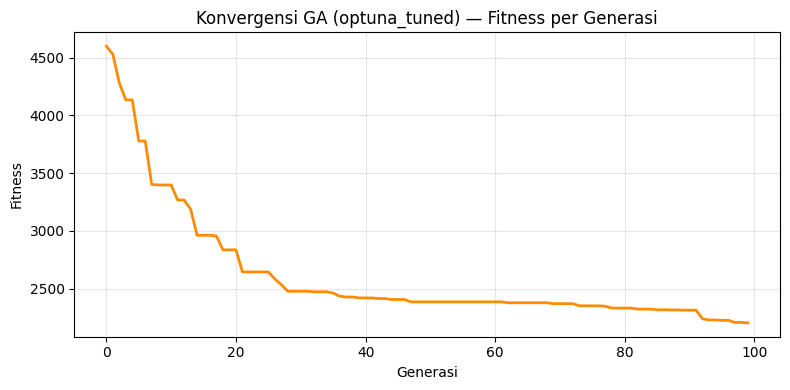

Grafik: konvergensi_ga_optuna_tuned.png

✨ Selesai! Peta meliuk jalan riil 'peta_rute_ga_optuna_tuned.html' berhasil diekspor!


In [21]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL B — GA DENGAN OVERPASS API                                ║
# ║  (Road condition = real OSM data: highway + bicycle + width)    ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# Cell ini hanya mengganti road condition matrix-nya.
# Semua logika GA (fitness, crossover, mutasi, seleksi) IDENTIK dengan Cell A.
# Jalankan Cell A dulu sebelum Cell B.
#
# Dependency: road_condition_batch.py harus sudah dijalankan dan
# menghasilkan road_condition_matrix_overpass.csv
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import requests
import random
import time
import json
import os

# ─────────────────────────────────────────────
# PARAMETER GA (sama dengan Cell A)
# ─────────────────────────────────────────────
POP_SIZE       = 100
N_GENERASI     = 100
TOURNAMENT_K   = 5
PROB_CROSSOVER = 0.85
PROB_MUTASI    = 0.15
N_ELITE        = 2
MAX_KM_USER    = 20.0

# ─────────────────────────────────────────────
# KONFIGURASI OVERPASS API
# ─────────────────────────────────────────────
OVERPASS_ENDPOINTS = [
    "https://overpass-api.de/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter",
]
REQUEST_TIMEOUT    = 40
DELAY_REQUEST      = 2.0
CACHE_FILE         = "osm_road_cache.json"
RADIUS_METER       = 300

# ─────────────────────────────────────────────
# 1. SCORING OSM
# ─────────────────────────────────────────────
HIGHWAY_SCORE = {
    "cycleway":       1.0, "path":           1.0,
    "footway":        1.2, "living_street":  1.5,
    "residential":    1.5, "unclassified":   2.0,
    "tertiary":       2.0, "tertiary_link":  2.0,
    "secondary":      3.0, "secondary_link": 3.0,
    "primary":        4.0, "primary_link":   4.0,
    "trunk":          5.0, "trunk_link":     5.0,
    "motorway":       5.0, "motorway_link":  5.0,
}

def hitung_skor_dari_tags(tags):
    skor = HIGHWAY_SCORE.get(tags.get("highway", ""), 2.5)
    bicycle = tags.get("bicycle", "")
    if bicycle in ("designated", "yes"):
        skor -= 0.5
    elif bicycle == "no":
        skor += 1.5
    try:
        w = float(str(tags.get("width", "")).replace("m", "").strip())
        if w >= 5.0:   skor -= 0.3
        elif w < 3.0:  skor += 0.8
    except (ValueError, TypeError):
        pass
    return round(max(1.0, min(5.0, skor)), 3)

# ─────────────────────────────────────────────
# 2. OVERPASS QUERY + CACHE
# ─────────────────────────────────────────────
def load_cache():
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE) as f:
            return json.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f)

def query_overpass(ql):
    for ep in OVERPASS_ENDPOINTS:
        try:
            r = requests.post(ep, data={"data": ql}, timeout=REQUEST_TIMEOUT,
                              headers={"User-Agent": "RouteOptimizationResearch/1.0"})
            if r.status_code == 200:
                return r.json().get("elements", [])
        except Exception as e:
            print(f"   [ERROR] {ep}: {e}")
    return None

def ambil_skor_area_node(lat, lon):
    query = f"""
[out:json][timeout:35];
way(around:{RADIUS_METER},{lat},{lon})
  ["highway"]
  ["highway"!~"footway|steps|pedestrian|construction|proposed|abandoned|path"];
out tags;
"""
    elements = query_overpass(query)
    if not elements:
        return None
    skor_list = [hitung_skor_dari_tags(el["tags"])
                 for el in elements if "highway" in el.get("tags", {})]
    if not skor_list:
        return None
    return {
        "best":   round(min(skor_list), 3),
        "median": round(float(np.median(skor_list)), 3),
        "worst":  round(max(skor_list), 3),
        "count":  len(skor_list)
    }

def skor_fallback_cluster(i, j, df_cluster):
    if i == 0 or j == 0:
        return 3.0
    return 1.5 if df_cluster.iloc[i-1]['Cluster_ID'] == df_cluster.iloc[j-1]['Cluster_ID'] else 4.0

def bangun_road_matrix_overpass(df_wisata, df_cluster,
                                output_file='road_condition_matrix_overpass.csv'):
    """
    Bangun road condition matrix menggunakan Overpass API (batch per node).
    Fallback ke proxy cluster jika API gagal.
    Hasil disimpan ke output_file agar tidak perlu query ulang.
    """
    # Kalau matrix sudah ada, langsung load
    if os.path.exists(output_file):
        print(f"Road condition matrix (Overpass) sudah ada: {output_file}")
        print("Langsung memuat dari file...\n")
        return pd.read_csv(output_file, index_col=0)

    depot_name        = "Hotel Sheraton Surabaya"
    depot_lat, depot_lon = -7.262015, 112.739727
    names = [depot_name] + df_wisata['Nama Destinasi'].tolist()
    lats  = [depot_lat]  + df_wisata['Latitude'].tolist()
    lons  = [depot_lon]  + df_wisata['Longitude'].tolist()
    num_nodes = len(names)

    cache       = load_cache()
    area_scores = {}

    print(f"{'='*55}")
    print(f"  Membangun Road Matrix via Overpass API (Batch)")
    print(f"  Target: {num_nodes} request (bukan {num_nodes*(num_nodes-1)})")
    print(f"  Estimasi: ~{num_nodes * (DELAY_REQUEST+3) / 60:.1f} menit")
    print(f"{'='*55}\n")

    api_ok = api_fb = 0
    for idx in range(num_nodes):
        key = f"node_{idx}_{lats[idx]:.5f}_{lons[idx]:.5f}"
        if key in cache:
            area_scores[idx] = cache[key]
            status = "CACHE"
        else:
            result           = ambil_skor_area_node(lats[idx], lons[idx])
            area_scores[idx] = result
            cache[key]       = result
            save_cache(cache)
            status = "API OK" if result else "FALLBACK"
            time.sleep(DELAY_REQUEST)

        if area_scores[idx]:
            api_ok += 1
            info = f"median={area_scores[idx]['median']}, count={area_scores[idx]['count']}"
        else:
            api_fb += 1
            info = "fallback cluster"
        print(f"  [{idx+1:02d}/{num_nodes}] {names[idx][:35]:<35} | {status} | {info}")

    print(f"\nQuery selesai: {api_ok} OK, {api_fb} fallback\n")
    print("Membangun matriks 51x51...")

    road_matrix  = np.zeros((num_nodes, num_nodes))
    fallback_cnt = 0

    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j:
                road_matrix[i][j] = 0.0
                continue
            ai, aj = area_scores[i], area_scores[j]
            if ai and aj:
                road_matrix[i][j] = round((ai["median"] + aj["median"]) / 2, 3)
            elif ai:
                road_matrix[i][j] = ai["median"]
            elif aj:
                road_matrix[i][j] = aj["median"]
            else:
                road_matrix[i][j] = skor_fallback_cluster(i, j, df_cluster)
                fallback_cnt += 1

    df_road = pd.DataFrame(road_matrix, index=names, columns=names)
    df_road.to_csv(output_file)
    print(f"Road matrix disimpan ke: {output_file}")
    print(f"Edge fallback: {fallback_cnt}/{num_nodes*(num_nodes-1)}\n")
    return df_road


# ─────────────────────────────────────────────
# 3. FUNGSI GA (identik Cell A — di-import ulang agar Cell B berdiri sendiri)
# ─────────────────────────────────────────────
def hitung_fitness_ga(solusi_multi_hari, matriks_jarak, matriks_elevasi,
                      matriks_jalan, df_cluster, max_km_user=MAX_KM_USER):
    w_jarak = 10.0; w_jalan = 5.0; w_penalti_cluster = 50.0
    fitness_total = 0.0; log_itinerary = []
    for idx_hari, rute in enumerate(solusi_multi_hari, start=1):
        if idx_hari % 2 != 0:
            nama_hari = "Sabtu (Jalan Berat)"; w_pf = 2.0;  w_pj = 5.0
        else:
            nama_hari = "Minggu (Recovery)";  w_pf = 15.0; w_pj = 25.0
        jarak_m = fatigue = skor_jalan = p_cluster = 0.0
        for k in range(len(rute) - 1):
            a, t  = rute[k], rute[k+1]
            dm    = matriks_jarak.iloc[a, t]
            dz    = matriks_elevasi.iloc[a, t]
            js    = matriks_jalan.iloc[a, t]
            jarak_m   += dm; skor_jalan += js
            if dz > 0 and dm > 0: fatigue += dm * ((dz/dm)**2) * 10.0
            else:                  fatigue += dm * 0.0001
            if a != 0 and t != 0:
                if df_cluster.iloc[a-1]['Cluster_ID'] != df_cluster.iloc[t-1]['Cluster_ID']:
                    p_cluster += w_penalti_cluster
        jkm  = jarak_m / 1000.0
        p_jarak   = max(0.0, jkm - max_km_user) * w_pj
        p_fatigue = fatigue * w_pf
        fitness_total += jkm*w_jarak + skor_jalan*w_jalan + p_jarak + p_fatigue + p_cluster
        log_itinerary.append({
            "Hari": f"Trip {idx_hari} ({nama_hari})",
            "Jarak (Km)": round(jkm, 2), "Fatigue Index": round(fatigue, 2),
            "Skor Jalan": round(skor_jalan, 2), "P_Jarak": round(p_jarak, 2),
            "P_Fatigue": round(p_fatigue, 2), "P_Cluster": round(p_cluster, 2),
        })
    return fitness_total, log_itinerary

def buat_kromosom_acak(n=50):
    k = list(range(1, n+1)); random.shuffle(k); return k

def decode_kromosom(kromo, matriks_jarak, max_km_user=MAX_KM_USER):
    max_m = max_km_user * 1000; hasil = []; sisa = list(kromo)
    while sisa:
        rute = [0]; jarak = 0.0
        while sisa:
            pos  = rute[-1]; tuj = sisa[0]
            dtuj = matriks_jarak.iloc[pos, tuj]
            if (jarak + dtuj > max_m) and (random.random() > 0.15): break
            rute.append(tuj); jarak += dtuj; sisa.pop(0)
        rute.append(0); hasil.append(rute)
    return hasil

def order_crossover(p1, p2):
    n = len(p1); a, b = sorted(random.sample(range(n), 2))
    anak = [None]*n; anak[a:b+1] = p1[a:b+1]
    sisa = [g for g in p2 if g not in anak[a:b+1]]
    ptr = 0
    for i in range(n):
        if anak[i] is None: anak[i] = sisa[ptr]; ptr += 1
    return anak

def swap_mutation(k, prob=PROB_MUTASI):
    k = k[:]
    if random.random() < prob:
        i, j = random.sample(range(len(k)), 2); k[i], k[j] = k[j], k[i]
    return k

def tournament_selection(pop, fit, k=TOURNAMENT_K):
    idx = random.sample(range(len(pop)), k)
    return pop[min(idx, key=lambda i: fit[i])][:]

def jalankan_ga_routing(matriks_jarak, matriks_elevasi, matriks_jalan,
                        df_cluster, label="",
                        pop_size=POP_SIZE, n_generasi=N_GENERASI, n_elite=N_ELITE):
    n_dest = len(matriks_jarak) - 1
    print(f"\n{'='*58}")
    print(f"  GA {label}")
    print(f"  Pop={pop_size} | Gen={n_generasi} | Elite={n_elite}")
    print(f"{'='*58}\n")

    populasi = [buat_kromosom_acak(n_dest) for _ in range(pop_size)]
    best_sol = None; best_fit = float('inf'); best_log = None; history = []

    for gen in range(1, n_generasi + 1):
        fit_list = []; log_list = []
        for k in populasi:
            rute = decode_kromosom(k, matriks_jarak)
            f, lg = hitung_fitness_ga(rute, matriks_jarak, matriks_elevasi,
                                       matriks_jalan, df_cluster)
            fit_list.append(f); log_list.append(lg)

        idx_best = int(np.argmin(fit_list))
        if fit_list[idx_best] < best_fit:
            best_fit = fit_list[idx_best]
            best_sol = decode_kromosom(populasi[idx_best], matriks_jarak)
            best_log = log_list[idx_best]
        history.append(best_fit)

        if gen % 10 == 0 or gen == 1:
            print(f"  Gen {gen:03d} | Best: {best_fit:,.2f} | "
                  f"Avg: {np.mean(fit_list):,.2f} | Hari: {len(best_sol)}")

        sorted_idx   = np.argsort(fit_list)
        elit         = [populasi[i][:] for i in sorted_idx[:n_elite]]
        generasi_baru = elit[:]
        while len(generasi_baru) < pop_size:
            p1 = tournament_selection(populasi, fit_list)
            p2 = tournament_selection(populasi, fit_list)
            if random.random() < PROB_CROSSOVER:
                a1 = order_crossover(p1, p2); a2 = order_crossover(p2, p1)
            else:
                a1, a2 = p1[:], p2[:]
            generasi_baru.append(swap_mutation(a1))
            if len(generasi_baru) < pop_size:
                generasi_baru.append(swap_mutation(a2))
        populasi = generasi_baru

    print(f"\n  Selesai! Fitness: {best_fit:,.2f} | Trip: {len(best_sol)} hari")
    return best_sol, best_fit, best_log, history


# ─────────────────────────────────────────────
# 4. OUTPUT
# ─────────────────────────────────────────────
def simpan_output_ga(solusi, log_itinerary, df_wisata, history, suffix="overpass"):
    import folium
    import matplotlib.pyplot as plt
    import requests

    csv_file  = f'itinerary_ga_{suffix}.csv'
    map_file  = f'peta_rute_ga_{suffix}.html'
    plot_file = f'konvergensi_ga_{suffix}.png'

    pd.DataFrame(log_itinerary).to_csv(csv_file, index=False)
    print(f"\nItinerary: {csv_file}")
    print(pd.DataFrame(log_itinerary).to_string(index=False))

    depot_lat, depot_lon = -7.262015, 112.739727
    names = ["Hotel Sheraton Surabaya"] + df_wisata['Nama Destinasi'].tolist()
    lats  = [depot_lat] + df_wisata['Latitude'].tolist()
    lons  = [depot_lon] + df_wisata['Longitude'].tolist()

    # 1. Inisialisasi Base Map
    m = folium.Map(location=[depot_lat, depot_lon], zoom_start=13)
    
    # Marker Depot (Hotel Sheraton)
    folium.Marker([depot_lat, depot_lon], tooltip="Hotel Sheraton (Depot Utama)",
                  icon=folium.Icon(color='red', icon='home')).add_to(m)

    # Palette Warna Per Hari Perjalanan
    warna_hari = ['blue', 'green', 'purple', 'orange', 'darkred', 'darkblue', 'darkgreen', 'cadetblue']
    
    print("\n📡 [VISUALISASI] Menembak OSRM Geometri rute riil jalanan Surabaya...")

    # 2. Loop Menggambar Rute Melik-Liuk Berdasarkan Jalan Nyata
    for idx_hari, rute in enumerate(solusi):
        warna = warna_hari[idx_hari % len(warna_hari)]
        
        # Ambil koordinat jalan riil turn-by-turn dari OSRM API
        coords_string = ";".join([f"{lons[node]},{lats[node]}" for node in rute])
        # Gunakan service 'route' dengan opsi overview=full & geometries=geojson
        url_route = f"http://router.project-osrm.org/route/v1/bike/{coords_string}?overview=full&geometries=geojson"
        
        try:
            res = requests.get(url_route, timeout=15).json()
            if res.get("code") == "Ok":
                # Mengambil data koordinat aspal jalan asli dari OSRM
                geometry_jalan = res["routes"][0]["geometry"]
                
                # Gambar garis meliuk-liuk di peta mengikuti jalan riil
                folium.GeoJson(
                    geometry_jalan,
                    style_function=lambda x, w=warna: {'color': w, 'weight': 4, 'opacity': 0.85},
                    tooltip=f"Trip Hari ke-{idx_hari+1}"
                ).add_to(m)
            else:
                # Fallback garis lurus jika server API OSRM mendadak sibuk
                folium.PolyLine([[lats[n], lons[n]] for n in rute], color=warna, weight=3, opacity=0.7).add_to(m)
        except Exception:
            folium.PolyLine([[lats[n], lons[n]] for n in rute], color=warna, weight=3, opacity=0.7).add_to(m)

        # 3. Menggambar Marker Tempat Wisata yang Dikunjungi Hari Ini
        for node in rute[1:-1]:
            folium.CircleMarker(
                [lats[node], lons[node]], 
                radius=7,
                color=warna, 
                fill=True,
                fill_color='white',
                fill_opacity=0.9,
                weight=3,
                tooltip=f"[Hari {idx_hari+1}] {names[node]}"
            ).add_to(m)

    m.save(map_file)
    print(f"✅ Peta Jalan Riil Berhasil Disimpan: {map_file}")

    # 4. Menggambar Grafik Konvergensi GA
    plt.figure(figsize=(8, 4))
    plt.plot(history, color='darkorange', linewidth=2)
    plt.title(f'Konvergensi GA ({suffix}) — Fitness per Generasi')
    plt.xlabel('Generasi'); plt.ylabel('Fitness')
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(plot_file, dpi=120); plt.show()
    print(f"Grafik: {plot_file}")


# ─────────────────────────────────────────────
# RUN — CELL B (INTEGRASI PENUH: OPTUNA DULUAN ──► LANGSUNG RUN 10 KALI)
# ─────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING) # Biar log Optuna gak menumpuk memenuhi layar

def objective(trial):
    # Tebakan kombinasi bumbu parameter dari Optuna di setiap Trial
    suggested_pop_size = trial.suggest_int('pop_size', 40, 120, step=20)
    suggested_pc       = trial.suggest_float('prob_crossover', 0.60, 0.95)
    suggested_pm       = trial.suggest_float('prob_mutasi', 0.05, 0.30)
    suggested_k        = trial.suggest_int('tournament_k', 3, 7)

    # Uji coba GA singkat (40 generasi) untuk ngetes kekuatan parameter tebakan Optuna
    _, fitness_akhir, _, _ = jalankan_ga_routing(
        matriks_jarak, matriks_elevasi, matriks_jalan_overpass, df_cluster,
        label=f"| [Optuna Tes Kombinasi Trial {trial.number}]",
        pop_size=suggested_pop_size, n_generasi=40, n_elite=2
    )
    return fitness_akhir

if __name__ == "__main__":
    try:
        print("Memuat data preprocessing...\n")
        matriks_jarak   = pd.read_csv('distance_matrix_surabaya.csv',  index_col=0)
        matriks_elevasi = pd.read_csv('elevation_matrix_surabaya.csv', index_col=0)
        df_cluster      = pd.read_csv('destinasi_clustered_real_distance.csv')
        df_wisata       = pd.read_csv('rute_sepeda_surabaya.csv')
        matriks_jalan_overpass = bangun_road_matrix_overpass(df_wisata, df_cluster)

        # ─────────────────────────────────────────────────────────
        # TAHAP 1: AI OPTUNA MENCARI PARAMETER TERBAIK
        # ─────────────────────────────────────────────────────────
        print("\n" + "="*65)
        print("🤖 [TAHAP 1] MENCARI PARAMETER GA PALING OPTIMAL VIA OPTUNA 🤖")
        print("="*65)
        
        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=10) # Memutar 10 kali kombinasi acak terarah
        
        # Ambil dan kunci hasil parameter terbaik dari Optuna
        best_p = study.best_params
        print("\n🏆 OPTUNA BERHASIL MENEMUKAN RACIKAN PARAMETER PALING JURAGAN:")
        print(f" - Pop Size     : {int(best_p['pop_size'])}")
        print(f" - Crossover Rate: {best_p['prob_crossover']:.4f}")
        print(f" - Mutation Rate : {best_p['prob_mutasi']:.4f}")
        print(f" - Tournament K  : {int(best_p['tournament_k'])}")
        print("="*65)

        # ─────────────────────────────────────────────────────────
        # TAHAP 2: EKSEKUSI FINAL 10 RUNS PAKAI PARAMETER DARI OPTUNA
        # ─────────────────────────────────────────────────────────
        print("\n⚡ [TAHAP 2] START FINAL MULTI-RUN BENCHMARKING PAKAI HASIL OPTUNA ⚡")
        print("=================================================================")
        
        TOTAL_RUNS = 10
        semua_history_runs = []
        fitness_terbaik_master = float('inf')
        rute_terbaik_master = None
        itinerary_terbaik_master = None
        history_terbaik_master = None
        run_terbaik_id = 0

        for id_run in range(1, TOTAL_RUNS + 1):
            print(f"\n▶️ MEMULAI PERCOBAAN FINAL [RUN {id_run}/{TOTAL_RUNS}]")
            
            # Eksekusi penuh 100 generasi menggunakan parameter yang sudah dikunci oleh Optuna
            rute, fitness, itinerary, history = jalankan_ga_routing(
                matriks_jarak, matriks_elevasi, matriks_jalan_overpass, df_cluster,
                label=f"| Run Final Hasil Tuning Optuna ke-{id_run}",
                pop_size=int(best_p['pop_size']), n_generasi=100, n_elite=2
            )
            
            semua_history_runs.append(history[-1])
            
            if fitness < fitness_terbaik_master:
                fitness_terbaik_master = fitness
                rute_terbaik_master = rute
                itinerary_terbaik_master = itinerary
                history_terbaik_master = history
                run_terbaik_id = id_run

        # ─────────────────────────────────────────────────────────
        # TAHAP 3: REKAPITULASI HASIL AKHIR
        # ─────────────────────────────────────────────────────────
        print("\n" + "="*65)
        print("📊 REKAPITULASI STATISTIK FINAL (FULL OPTUNA-BASED)")
        print("="*65)
        for r_id, fit_akhir in enumerate(semua_history_runs, 1):
            print(f" - Skor Akhir Run {r_id:02d} : {fit_akhir:,.2f}")
            
        print(f"\n🏆 Solusi Rute Terbaik Terjadi Pada: [RUN {run_terbaik_id}]")
        print(f"🎯 Skor Fitness Paling Optimal Global: {fitness_terbaik_master:,.2f}")
        print("="*65)

        # Cetak output peta meliuk dan csv berdasarkan RUN TERBAIK bentukan parameter Optuna
        simpan_output_ga(rute_terbaik_master, itinerary_terbaik_master, df_wisata, history_terbaik_master, suffix="optuna_tuned")
        print(f"\n✨ Selesai! Peta meliuk jalan riil 'peta_rute_ga_optuna_tuned.html' berhasil diekspor!")

    except FileNotFoundError as e:
        print(f"File tidak ditemukan: {e}")
    except Exception as e:
        import traceback; traceback.print_exc()